# Lotka Volterra equations

Also known as predator-prey equations, describe the variation in populations of two species which interact via predation. For example wolves (predators) and deer (prey). This is a classical model to represent the dynamic of two populations.

Let $\alpha > 0, \beta >0, \delta > 0  \text{and}  \gamma > 0$. The system is given by:
$$
\begin{align}
\frac{dx}{dt} = \alpha x - \beta xy \\
\frac{dy}{dt} = -\delta y + \delta \gamma x
\end{align}
$$
where:
- x represents prey population
- y predators population.
- $\alpha$: natural growth rate of the pray population in the absernce of predators
- $\beta$: the rate of which predator capture prey
- $\delta$: the efficiency of converting consumed prey into predator offsipring
- $\gamma$: the natural death rate of predator in the absence of prey  
It's a system of first-order non-linear ordinary differential equations

Typical Parameters values: a = 1.1, b = 0.4, delta = 0.1, gamma = 0.4

### Problem reformulation
We pose,  
$$
X = 
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$
and rewrite the problem above as
$$
\frac{dX}{dt} = 
\begin{bmatrix}
x(\alpha - \beta y) \\
y(-\delta + \gamma x)
\end{bmatrix}
= f(X)
$$
Remark: It's an autonomous problem

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate
import ipywidgets as ipw

In [2]:
# Numerical Simulation - Settings
alpha = 1 # mortality rate due ot predators
beta = 1
delta = 1
gamma = 1
x0 = 4
y0 = 2

def derivative(X, t, alpha, beta, delta, gamma):
    x, y = X
    dotx = x * (alpha-beta * y)
    doty = y * (-delta + gamma * x)
    return np.array([dotx, doty])

In [3]:
# Solving with odeint
Nt = 1000
tmax = 30
t = np.linspace(0., tmax, Nt)
X0 = [x0, y0]
res = integrate.odeint(derivative, X0, t, args = (alpha, beta, delta, gamma))
x, y = res.T


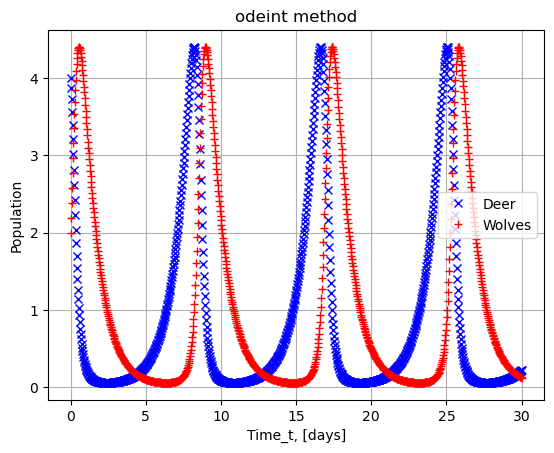

In [4]:
x.shape, y.shape

plt.figure()

plt.plot(t, x, 'xb', label = 'Deer')
plt.plot(t, y, '+r', label='Wolves')
plt.title("odeint method")
plt.grid()
plt.xlabel('Time_t, [days]')
plt.ylabel('Population')
plt.legend()
plt.show()

In [5]:
import random
import matplotlib.cm as cm

In [8]:
nums = np.random.random((10, len(betas)))
betas, nums

(array([0.9, 1. , 1.1, 1.2, 1.3]),
 array([[0.838403  , 0.10263557, 0.59714685, 0.12162145, 0.77928145],
        [0.04905247, 0.36574393, 0.38418813, 0.34241995, 0.81900019],
        [0.93927011, 0.11424458, 0.17078544, 0.99319379, 0.28273805],
        [0.65794449, 0.51787328, 0.39850652, 0.59829393, 0.58116137],
        [0.28380741, 0.56358592, 0.60503442, 0.28801468, 0.08928003],
        [0.11756935, 0.61263893, 0.91340256, 0.60473838, 0.94596179],
        [0.57034127, 0.79457298, 0.46462569, 0.3797486 , 0.13357671],
        [0.12063269, 0.03265323, 0.78449989, 0.91048921, 0.46153467],
        [0.26769957, 0.28405884, 0.94438632, 0.57686672, 0.91141683],
        [0.70617563, 0.75262077, 0.71587608, 0.81605118, 0.93862385]]))

Text(0, 0.5, 'Wolves')

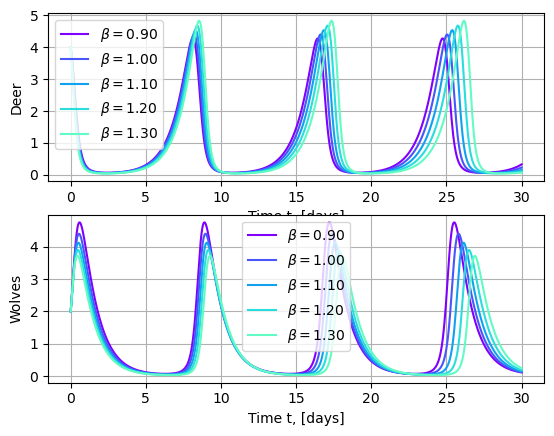

In [19]:
# Plot for different values of beta

betas = np.arange(0.9, 1.4, 0.1) # from 0.9-1.4 with step 0.1

nums = np.random.random((10, len(betas)))
colors = cm.rainbow(np.linspace(0,1, nums.shape[0])) # generate the color for each dataset

fig, ax = plt.subplots(2,1)

for beta, i in zip(betas, range(len(betas))):
    res = integrate.odeint(derivative, X0, t, args = (alpha, beta, gamma, delta))
    ax[0].plot(t, res[:, 0], color = colors[i], linestyle = '-', label = r"$\beta = $" + "{0:.2f}".format(beta))
    ax[1].plot(t, res[:, 1], color = colors[i], linestyle = '-', label = r"$\beta = $" + "{0:.2f}".format(beta))
    ax[0].legend()
    ax[1].legend()

ax[0].grid()
ax[1].grid()
ax[0].set_xlabel('Time t, [days]')
ax[0].set_ylabel('Deer')
ax[1].set_xlabel('Time t, [days]')
ax[1].set_ylabel('Wolves')

In [21]:
nums.shape

(10, 5)

### Phase portrait
The phase portrait is a geometrical representation of the trajectories of a dynamical system in the phase space (axes corresponding to the state variables x and y). It is a tool for visualizing and analyzing the behavior of dynamic systems like Lotka-Volterra equations.

Text(0.5, 1.0, 'Deer vs Wolves')

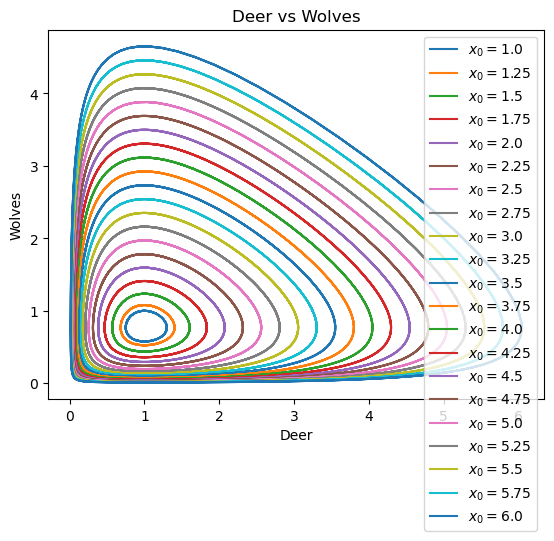

In [22]:
# Behavior of the system with different deer initial population

plt.figure()
IC = np.linspace(1.0, 6.0, 21) # inital conditions for deer populations (prey)
for deer in IC:
    X0 = [deer, 1.0]
    Xs = integrate.odeint(derivative, X0, t, args=(alpha, beta, delta, gamma))
    plt.plot(Xs[:, 0], Xs[:, 1], "-", label = "$x_0 =$" + str(X0[0]))
plt.xlabel('Deer')
plt.ylabel('Wolves')
plt.legend()
plt.title('Deer vs Wolves')

These curves illustrate the system is periodic because they are closed

In [24]:
1/alpha

1.0

Solving with explicit Euler method

In [27]:
def Euler(func, X0, t, alpha, beta, delta, gamma):
    '''Euler Solver'''
    dt = t[1]-t[0]
    nt = len(t)
    X = np.zeros([nt, len(X0)])
    X[0] = X0
    for i in range(nt-1):
        X[i+1] = X[i] + func(X[i], t[i], alpha, beta, delta, gamma) * dt
    return X

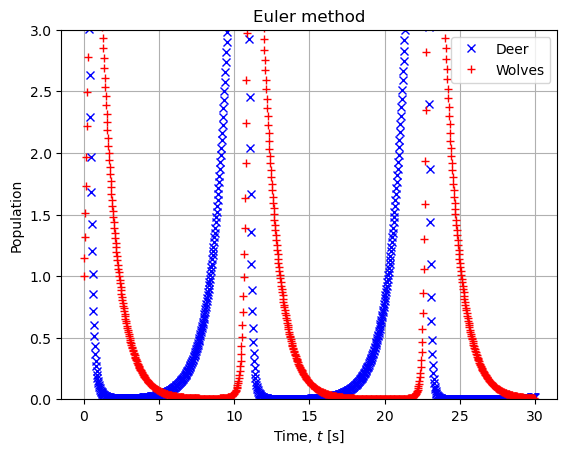

In [29]:
Xe = Euler(derivative, X0, t, alpha, beta, delta, gamma)
plt.figure()
plt.title('Euler method')
plt.plot(t, Xe[:,0], 'xb', label='Deer')
plt.plot(t, Xe[:, 1], '+r', label='Wolves')
plt.grid()
plt.xlabel("Time, $t$ [s]")
plt.ylabel('Population')
plt.ylim([0., 3.])
plt.legend(loc='best')

plt.show()

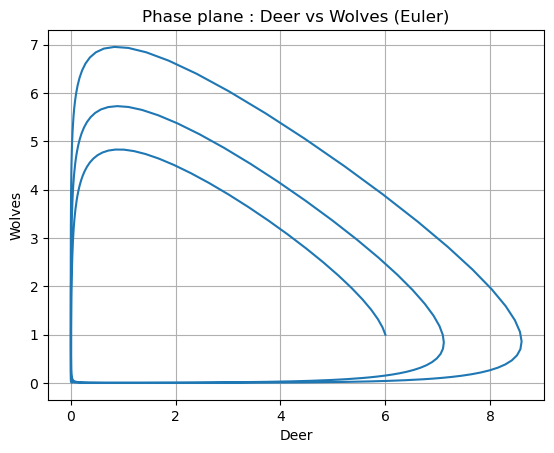

In [30]:
plt.figure()
plt.plot(Xe[:, 0], Xe[:, 1], "-")
plt.xlabel("Deer")
plt.ylabel("Wolves")
plt.grid()
plt.title("Phase plane : Deer vs Wolves (Euler)");

### With RK$

In [36]:
def RK4(func, X0, t, alpha, beta, delta, gamma):
    '''
    Runge Katta 4 Solver 
    '''
    dt = t[1]-t[0]
    nt=len(t)
    X = np.zeros([nt, len(X0)])
    X[0] = X0
    for i in range(nt-1):
        k1 = func(X[i], t[i], alpha, beta, delta, gamma)
        k2 = func(X[i] + dt/2. * k1, t[i] + dt/2., alpha, beta, delta, gamma)
        k3 = func(X[i] + dt/2. * k2, t[i] + dt/2., alpha,  beta, delta, gamma)
        k4 = func(X[i] + dt    * k3, t[i] + dt, alpha,  beta, delta, gamma)
        X[i+1] = X[i] + dt / 6. * (k1 + 2. * k2 + 2. * k3 + k4)
    return X

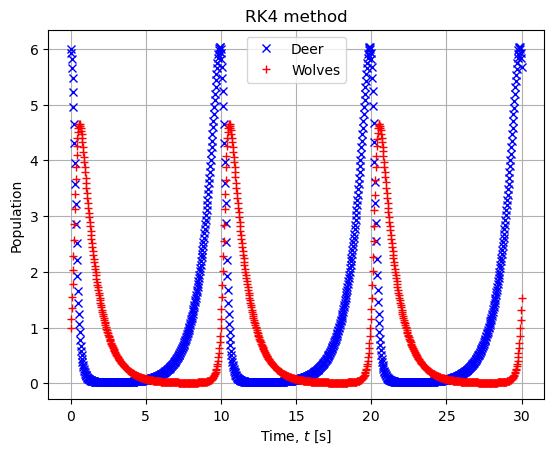

In [37]:
Xrk4 = RK4(derivative, X0, t, alpha, beta, delta, gamma)
plt.figure()
plt.title("RK4 method")
plt.plot(t, Xrk4[:, 0], 'xb', label = 'Deer')
plt.plot(t, Xrk4[:, 1], '+r', label = "Wolves")
plt.grid()
plt.xlabel("Time, $t$ [s]")
plt.ylabel('Population')
plt.legend(loc = "best")

plt.show()

Text(0.5, 1.0, 'Phase plane : Deer vs Wolves (RK4)')

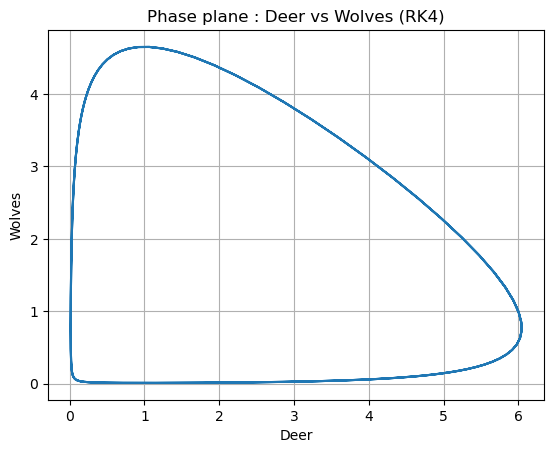

In [38]:
plt.figure()
plt.plot(Xrk4[:, 0], Xrk4[:, 1], "-")
plt.xlabel("Deer")
plt.ylabel("Wolves")
plt.grid()
plt.title("Phase plane : Deer vs Wolves (RK4)")

## Implement SBI in lotka voltera equations

- 4 unknown parameters (a, b, d, and c)
- initial values: x0 = 100, y0 = 50
- a, b, delta, gamma uniform priors in the interval [-1, 1.5]


In [1]:
import lfi
import torch 
import torch.nn as nn

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
import numpy as np
import torch
from scipy.integrate import solve_ivp
from torchdiffeq import odeint

In [3]:
# True parameters
#alpha, beta, delta, gamma = 1.1, 0.4, 0.1, 0.4
true_theta = torch.tensor([[1.1, 0.4, 0.1, 0.4]])  # Shape (1, 4) for batch processing

# t_span, n_steps etc default values of the simulator
obs = lfi.simulators.LotkaVolterraSimulator(4, 2)
obs = obs.sample_pytorch(true_theta) # Shape (1,100,2)
obs.shape

torch.Size([1, 200])

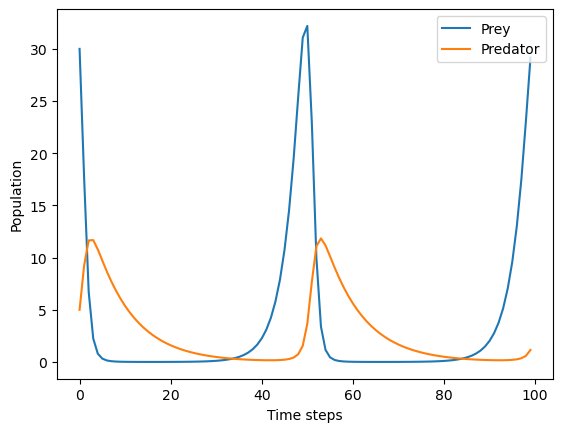

In [19]:
import matplotlib.pyplot as plt
observation = obs.reshape(1, 100, 2).squeeze(0)
observation.shape
plt.plot(observation[:,0], label='Prey')
plt.plot(observation[:,1], label='Predator')
plt.legend()
plt.xlabel('Time steps')
plt.ylabel('Population')
plt.show()

In [4]:
# Parameters
prior_dim = 4
simulator_dim_y = 2
nof_observations = 1
# Call the intervals as tensors, so that torch.utils can handle
prior_low = torch.tensor([0.5, 0.1, 0.01, 0.1], dtype=torch.float32)
prior_high = torch.tensor([2, 0.8, 0.5, 0.8], dtype=torch.float32)


In [5]:
prior_low, prior_high

(tensor([0.5000, 0.1000, 0.0100, 0.1000]),
 tensor([2.0000, 0.8000, 0.5000, 0.8000]))

In [6]:
# Model parameters
num_components = 10
budget=500
nof_samples = 100
batch_size=1000

In [7]:
# Define embedding (Network that makes the 2D outputs to flatten)
embedding_net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(100*2, 10), # Adjust output dim as needed
    nn.ReLU()
)

In [8]:
prior = lfi.priors.UniformPrior(low=prior_low, high=prior_high, dim=prior_dim)
#theta = prior.sample_pytorch(1)
simulator=lfi.simulators.LotkaVolterraSimulator(dim=prior_dim, dim_y=simulator_dim_y)
#observation = embedding_net(obs)
obs.shape

torch.Size([1, 200])

In [9]:
inference = lfi.inference.from_sbi.NPEASingleRound(
    prior=prior,
    simulator=simulator,
    observation=obs
)

In [10]:
inference.fit(
    budget=budget    
)

  0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 82 epochs.

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [12]:
samples = inference.sample(nof_samples=nof_samples)

Drawing 100 posterior samples:   0%|          | 0/100 [00:00<?, ?it/s]

In [13]:
samples.shape

(100, 4)

<Figure size 640x480 with 0 Axes>

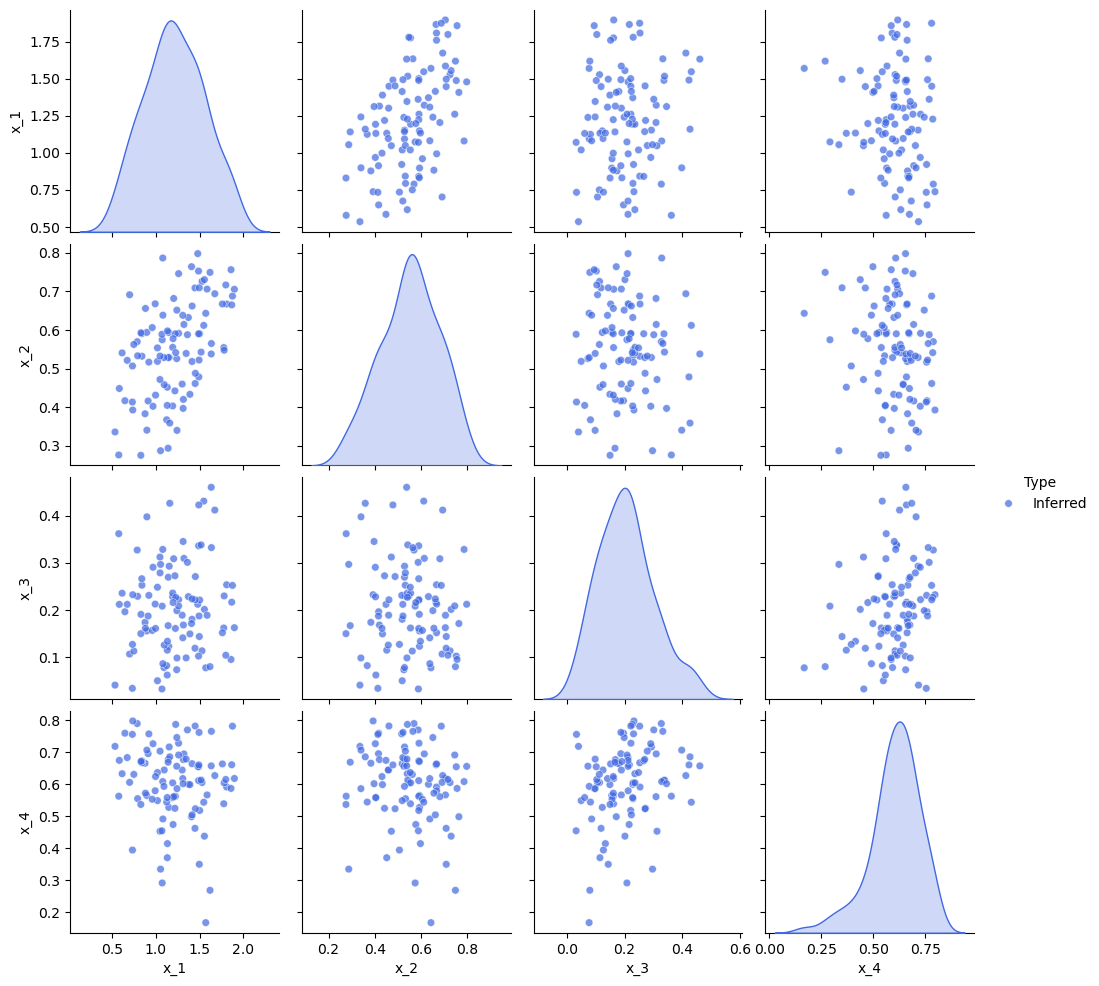

In [18]:
lfi.visualization.plot_pairwise_posterior(
    samples)
plt.show()